#### Impact of varying time dimension size on model performance across two datasets.

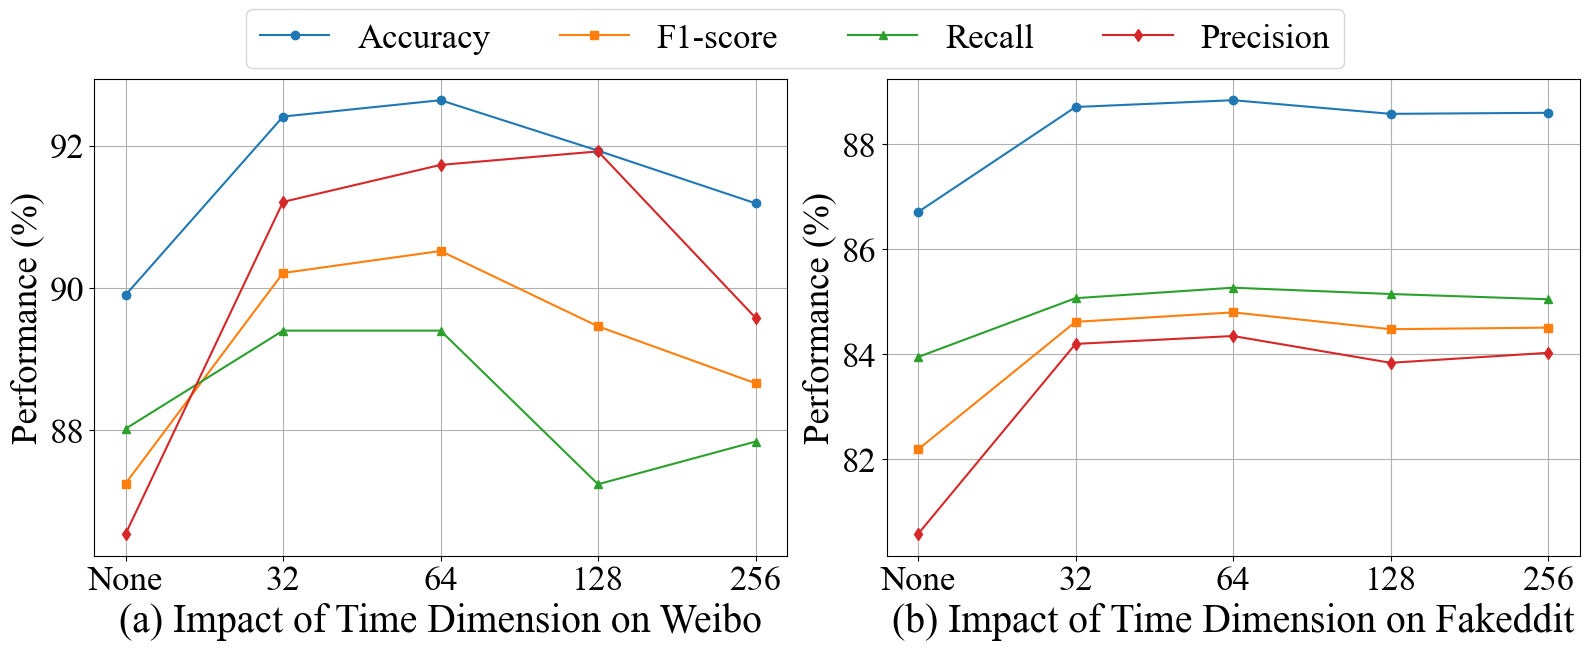

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
import matplotlib.font_manager as font_manager
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'

font_path = 'fonts/Times New Roman.ttf'
font_manager.fontManager.addfont(font_path)
rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.family'] = 'Times New Roman'

time_dims_true = ["None", 32, 64, 128, 256]
x_pos = [0, 1, 2, 3, 4]

accuracy_1 =  [89.90, 92.41, 92.64, 91.93, 91.19]
precision_1 = [86.54, 91.21, 91.73, 91.92, 89.58]
recall_1 =    [88.02, 89.40, 89.40, 87.24, 87.84]
f1_score_1 =  [87.25, 90.21, 90.52, 89.46, 88.66]

accuracy_2 =  [86.71, 88.71, 88.84, 88.58, 88.60]
precision_2 = [80.58, 84.20, 84.35, 83.84, 84.03]
recall_2 =    [83.95, 85.07, 85.27, 85.15, 85.05]
f1_score_2 =  [82.19, 84.62, 84.80, 84.48, 84.51]

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

lines = []
labels = ['Accuracy', 'F1-score', 'Recall', 'Precision']

lines.append(axes[0].plot(x_pos, accuracy_1, marker='o')[0])
lines.append(axes[0].plot(x_pos, f1_score_1, marker='s')[0])
lines.append(axes[0].plot(x_pos, recall_1, marker='^')[0])
lines.append(axes[0].plot(x_pos, precision_1, marker='d')[0])
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(time_dims_true, fontsize=25)
axes[0].tick_params(axis='y', labelsize=25)
axes[0].set_xlabel('(a) Impact of Time Dimension on Weibo', fontsize=28.5)
axes[0].set_ylabel('Performance (%)', fontsize=26.5)
axes[0].grid(True)

axes[1].plot(x_pos, accuracy_2, marker='o')
axes[1].plot(x_pos, f1_score_2, marker='s')
axes[1].plot(x_pos, recall_2, marker='^')
axes[1].plot(x_pos, precision_2, marker='d')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(time_dims_true, fontsize=25)
axes[1].tick_params(axis='y', labelsize=25)
axes[1].set_xlabel('(b) Impact of Time Dimension on Fakeddit', fontsize=28.5)
axes[1].set_ylabel('Performance (%)', fontsize=26.5)
axes[1].grid(True)

fig.legend(lines, labels, loc='upper center', ncol=4, fontsize=25, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.savefig('time_dimension_comparison_dual.svg', format='svg')
plt.show()


### Comparison of token aggregation strategies on Weibo and Fakeddit datasets.

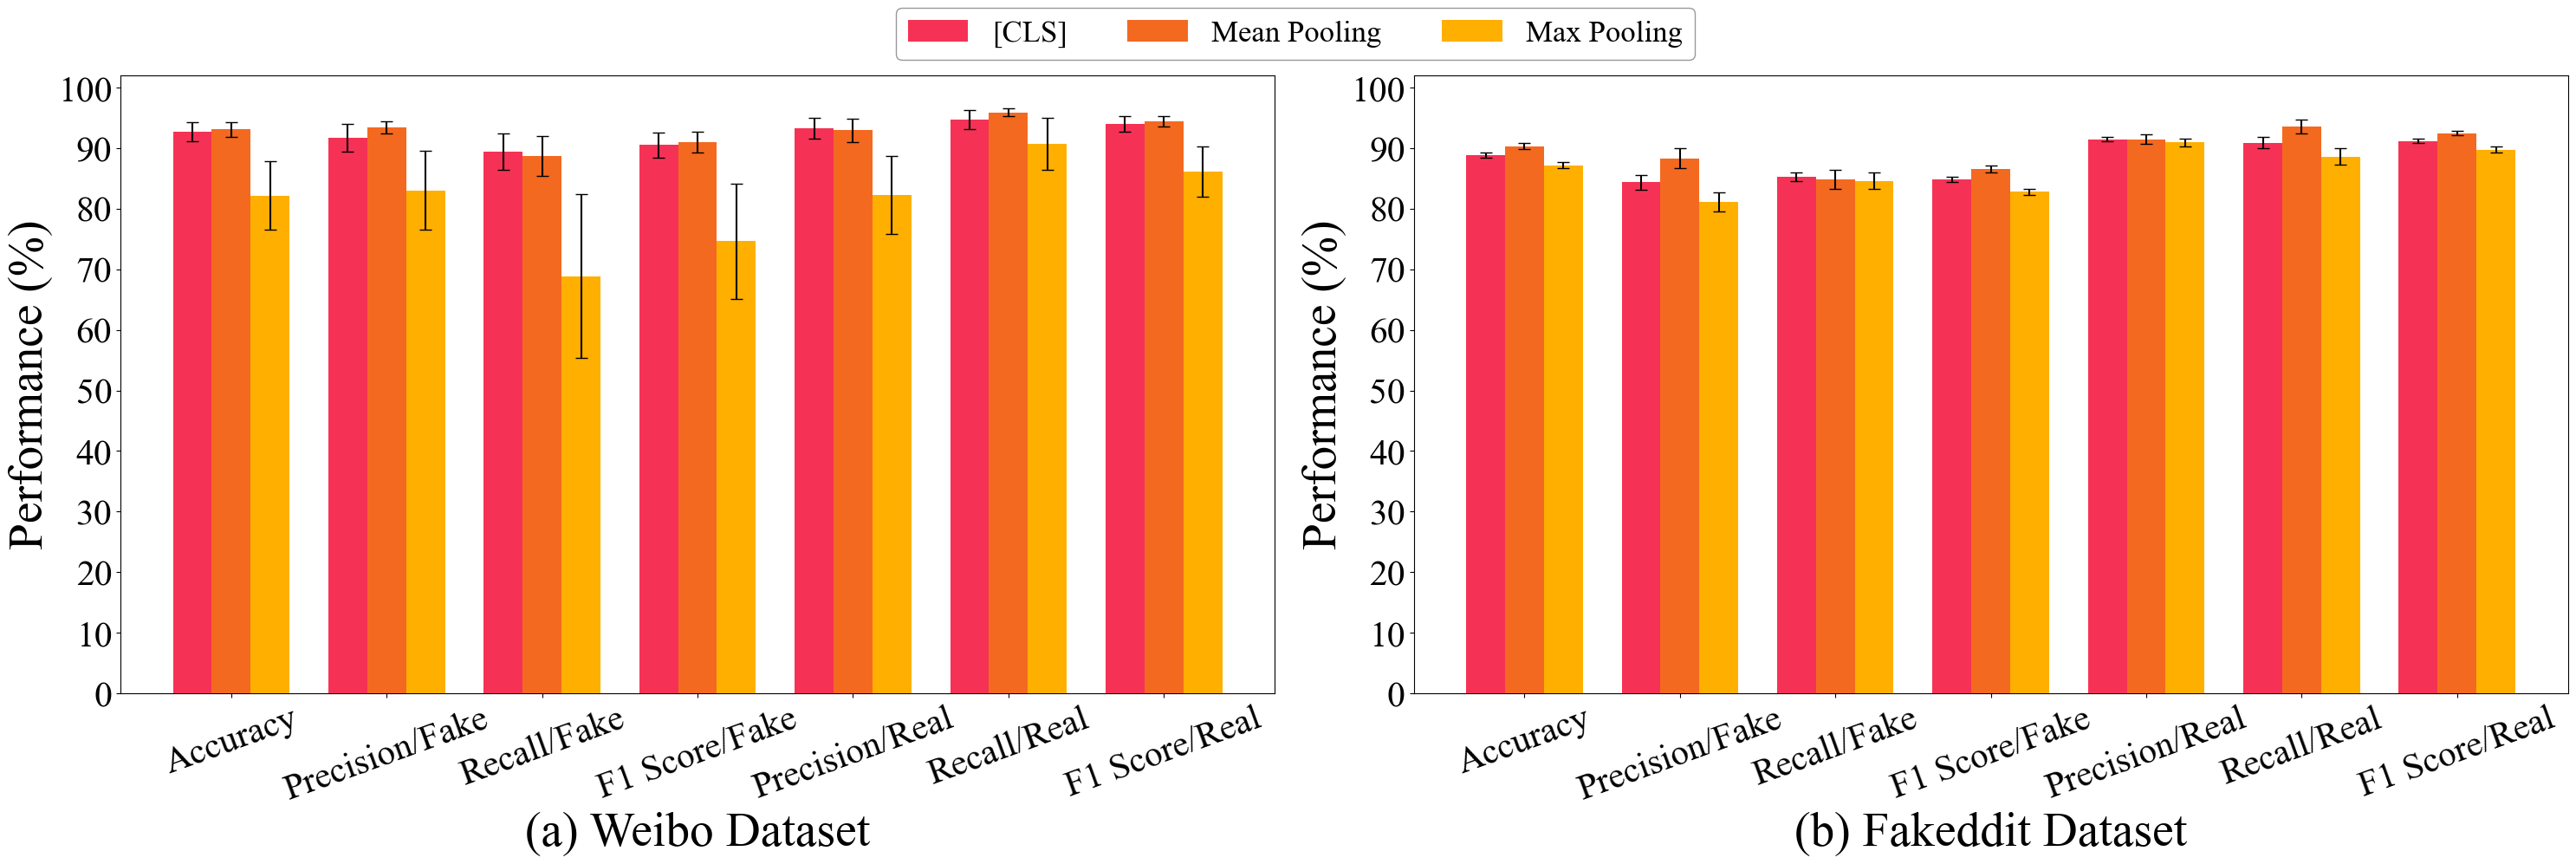

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
import matplotlib.font_manager as font_manager
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
font_path = 'fonts/Times New Roman.ttf'
font_manager.fontManager.addfont(font_path)
rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.family'] = 'Times New Roman'

metrics = ['Accuracy', 'Precision/Fake', 'Recall/Fake', 'F1 Score/Fake',
           'Precision/Real', 'Recall/Real', 'F1 Score/Real']
x = np.arange(len(metrics))
width = 0.25

cls_values_A = [92.64, 91.73, 89.40, 90.52, 93.26, 94.75, 93.99]
mean_values_A = [93.08, 93.39, 88.71, 90.95, 92.95, 95.92, 94.40]
max_values_A = [82.14, 83.02, 68.88, 74.63, 82.26, 90.73, 86.13]

cls_errors_A = [1.57, 2.30, 2.99, 2.09, 1.77, 1.56, 1.27]
mean_errors_A = [1.18, 0.98, 3.34, 1.70, 1.90, 0.70, 0.89]
max_errors_A = [5.67, 6.54, 13.55, 9.54, 6.49, 4.30, 4.11]

cls_values_B = [88.84, 84.35, 85.27, 84.80, 91.48, 90.89, 91.18]
mean_values_B = [90.34, 88.32, 84.82, 86.51, 91.47, 93.52, 92.48]
max_values_B = [87.15, 81.08, 84.60, 82.78, 90.92, 88.62, 89.75]

cls_errors_B = [0.42, 1.24, 0.72, 0.45, 0.33, 0.91, 0.37]
mean_errors_B = [0.46, 1.66, 1.55, 0.60, 0.74, 1.15, 0.40]
max_errors_B = [0.50, 1.56, 1.32, 0.49, 0.61, 1.32, 0.48]

fig, axes = plt.subplots(1, 2, figsize=(30, 10))

colors = ['#f53255', '#f46920', '#ffaf00']

axes[0].bar(x - width, cls_values_A, width=width, yerr=cls_errors_A, capsize=5,
            label='[CLS]', color=colors[0], zorder=3)
axes[0].bar(x, mean_values_A, width=width, yerr=mean_errors_A, capsize=5,
            label='Mean Pooling', color=colors[1], zorder=3)
axes[0].bar(x + width, max_values_A, width=width, yerr=max_errors_A, capsize=5,
            label='Max Pooling', color=colors[2], zorder=3)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, fontsize=30, rotation=20)
axes[0].set_xlabel('(a) Weibo Dataset', fontsize=40)
axes[0].set_yticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
axes[0].set_ylabel('Performance (%)', fontsize=40)
axes[0].tick_params(axis='y', labelsize=30)

axes[1].bar(x - width, cls_values_B, width=width, yerr=cls_errors_B, capsize=5,
            label='[CLS]', color=colors[0], zorder=3)
axes[1].bar(x, mean_values_B, width=width, yerr=mean_errors_B, capsize=5,
            label='Mean Pooling', color=colors[1], zorder=3)
axes[1].bar(x + width, max_values_B, width=width, yerr=max_errors_B, capsize=5,
            label='Max Pooling', color=colors[2], zorder=3)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, fontsize=30, rotation=20)
axes[1].set_xlabel('(b) Fakeddit Dataset', fontsize=40)
axes[1].set_yticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
axes[1].set_ylabel('Performance (%)', fontsize=40)
axes[1].tick_params(axis='y', labelsize=30)

axes[0].set_ylim(0, 102)
axes[1].set_ylim(0, 102)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    fontsize=25,
    ncol=3,
    frameon=True,
    facecolor='white',
    edgecolor='gray',
    bbox_to_anchor=(0.5, 1.01)
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.savefig('feature_strategy_comparison_dual.svg', format='svg')
plt.show()


### omparison of the “full model” and the “w/o time” variant on the Weibo and Fakeddit datasets | Wilcoxon

['full model' 'w/o time']


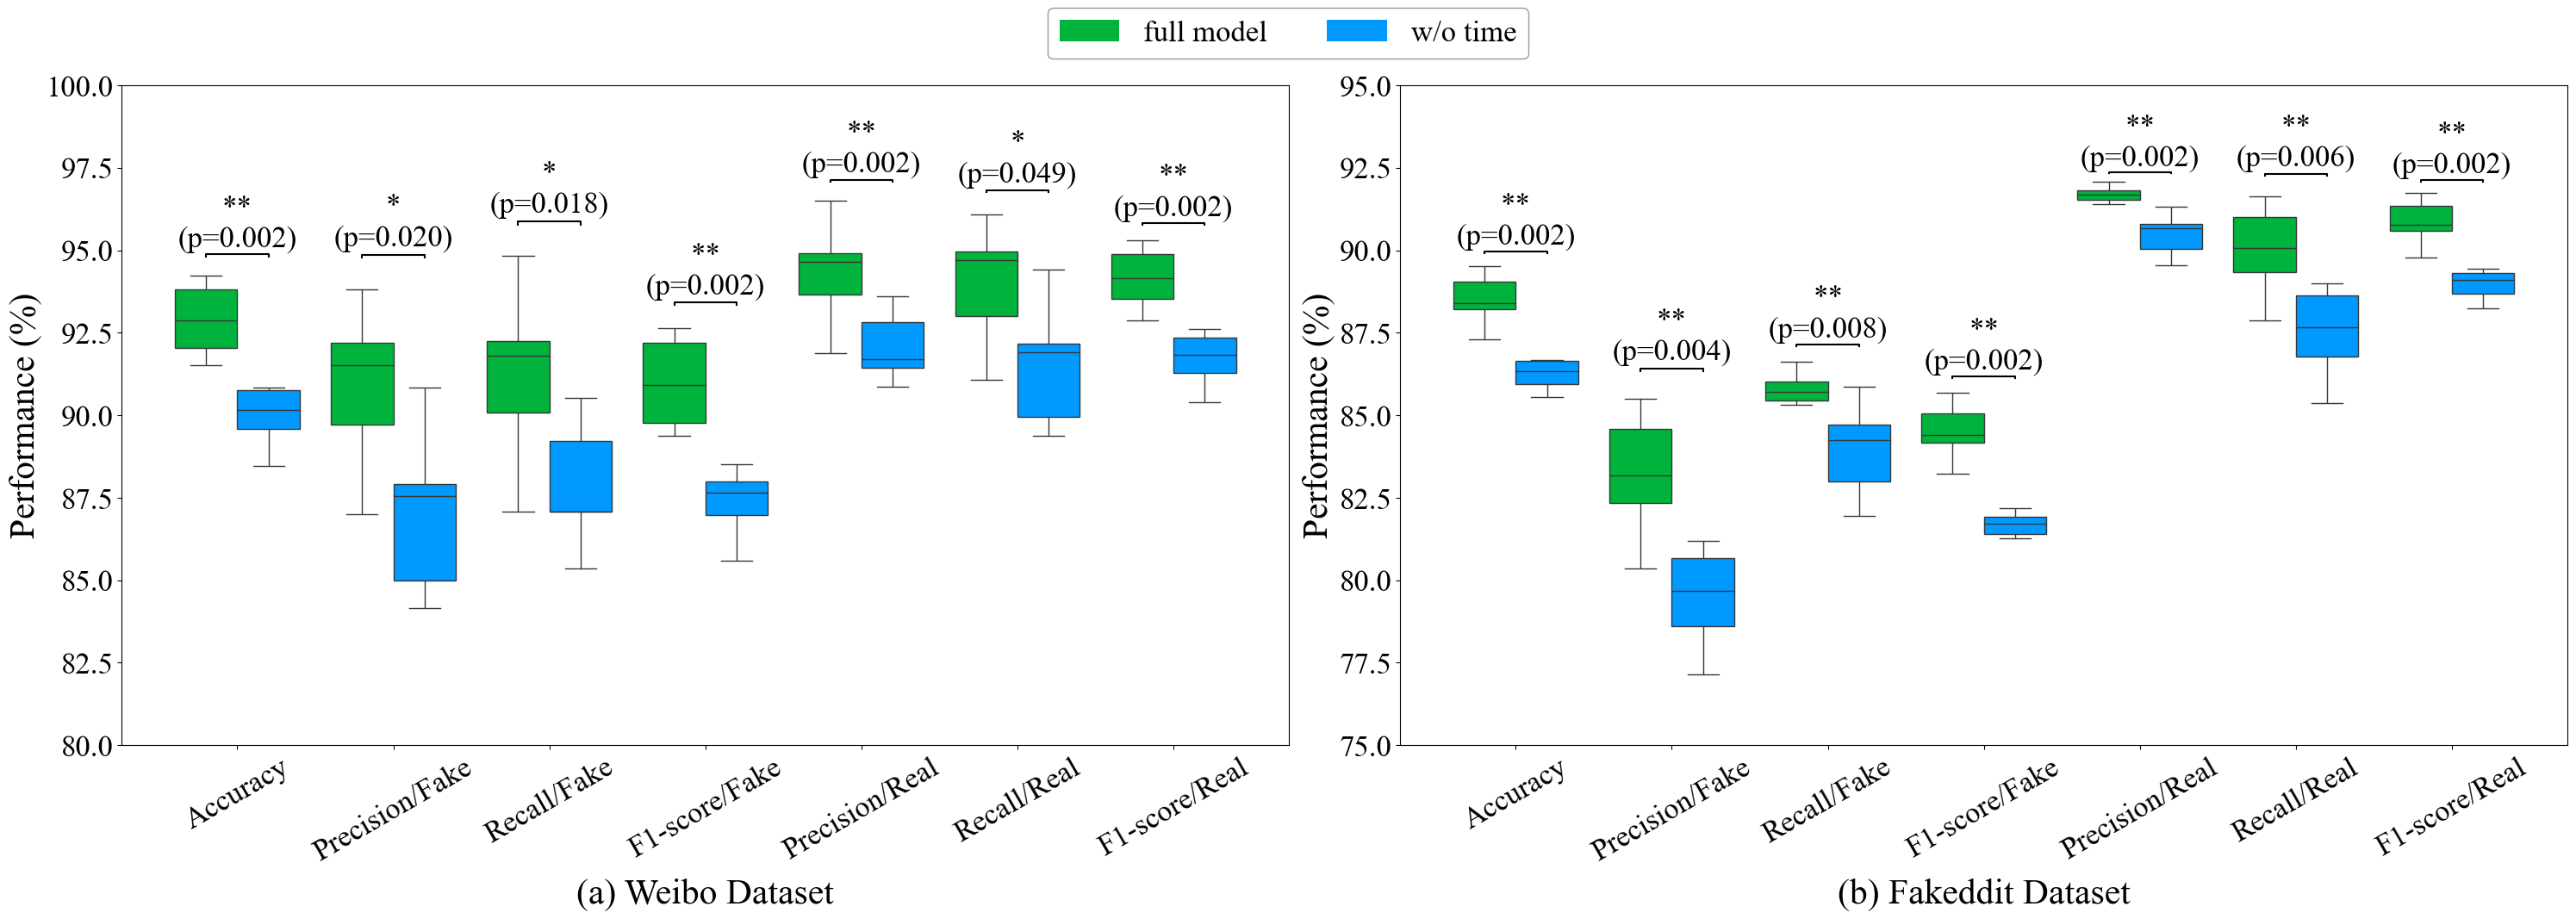

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import pandas as pd
from scipy.stats import wilcoxon
from matplotlib import rcParams
import matplotlib.font_manager as font_manager
import matplotlib as mpl
import copy
import numpy as np

mpl.rcParams['svg.fonttype'] = 'none'
font_path = 'fonts/Times New Roman.ttf'
font_manager.fontManager.addfont(font_path)
rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.family'] = 'Times New Roman'

metrics = ['Accuracy', 'Precision/Fake', 'Recall/Fake', 'F1-score/Fake', 'Precision/Real', 'Recall/Real', 'F1-score/Real']

dataset1_a = {
    'Accuracy':        [0.9423728813559322, 0.9254237288135593, 0.9152542372881356, 0.9186440677966101, 0.9288135593220339, 0.9152542372881356, 0.9389830508474576, 0.9423728813559322, 0.9288135593220339, 0.9355932203389831],
    'Precision/Fake':  [0.9380530973451328, 0.9122807017543859, 0.8699186991869918, 0.9181818181818182, 0.9203539823008849, 0.8699186991869918, 0.9224137931034483, 0.9304347826086956, 0.905982905982906, 0.8943089430894309],
    'Recall/Fake':     [0.9137931034482759, 0.896551724137931, 0.9224137931034483, 0.8706896551724138, 0.896551724137931, 0.9224137931034483, 0.9224137931034483, 0.9224137931034483, 0.9137931034482759, 0.9482758620689655],
    'F1-score/Fake':   [0.925764192139738, 0.9043478260869565, 0.895397489539749, 0.8938053097345132, 0.9082969432314411, 0.895397489539749, 0.9224137931034483, 0.9264069264069265, 0.9098712446351931, 0.9205020920502092],
    'Precision/Real':  [0.945054945054945, 0.9337016574585635, 0.9476744186046512, 0.918918918918919, 0.9340659340659341, 0.9476744186046512, 0.9497206703910615, 0.95, 0.9438202247191011, 0.9651162790697675],
    'Recall/Real':     [0.9608938547486033, 0.9441340782122905, 0.9106145251396648, 0.9497206703910615, 0.9497206703910615, 0.9106145251396648, 0.9497206703910615, 0.9553072625698324, 0.9385474860335196, 0.9273743016759777],
    'F1-score/Real':   [0.9529085872576177, 0.9388888888888889, 0.9287749287749287, 0.9340659340659341, 0.9418282548476454, 0.9287749287749287, 0.9497206703910615, 0.9526462395543176, 0.9411764705882353, 0.9458689458689459],
}
dataset1_b = {
    'Accuracy':        [0.9016949152542373, 0.8949152542372881, 0.9084745762711864, 0.8847457627118644, 0.9084745762711864, 0.8983050847457628, 0.9050847457627119, 0.9084745762711864, 0.9016949152542373, 0.888135593220339],
    'Precision/Fake':  [0.8536585365853658, 0.8455284552845529, 0.908256880733945, 0.8416666666666667, 0.8739495798319328, 0.8771929824561403, 0.8793103448275862, 0.8938053097345132, 0.8782608695652174, 0.8487394957983193],
    'Recall/Fake':     [0.9051724137931034, 0.896551724137931, 0.853448275862069, 0.8706896551724138, 0.896551724137931, 0.8620689655172413, 0.8793103448275862, 0.8706896551724138, 0.8706896551724138, 0.8706896551724138],
    'F1-score/Fake':   [0.8786610878661087, 0.8702928870292888, 0.88, 0.8559322033898306, 0.8851063829787233, 0.8695652173913043, 0.8793103448275862, 0.8820960698689956, 0.8744588744588745, 0.8595744680851064],
    'Precision/Real':  [0.936046511627907, 0.9302325581395349, 0.9086021505376344, 0.9142857142857143, 0.9318181818181818, 0.9116022099447514, 0.9217877094972067, 0.9175824175824175, 0.9166666666666666, 0.9147727272727273],
    'Recall/Real':     [0.8994413407821229, 0.8938547486033519, 0.9441340782122905, 0.8938547486033519, 0.9162011173184358, 0.9217877094972067, 0.9217877094972067, 0.9329608938547486, 0.9217877094972067, 0.8994413407821229],
    'F1-score/Real':   [0.9173789173789174, 0.9116809116809117, 0.9260273972602739, 0.903954802259887, 0.923943661971831, 0.9166666666666666, 0.9217877094972067, 0.925207756232687, 0.9192200557103064, 0.9070422535211268],
}

dataset2_a = {
    'Accuracy':        [0.8833333333333333, 0.8817460317460317, 0.8952380952380953, 0.873015873015873, 0.8865079365079365, 0.8916666666666667, 0.8777777777777778, 0.8829365079365079, 0.8924603174603175, 0.8845238095238095],
    'Precision/Fake':  [0.8233471074380165, 0.8232848232848233, 0.854978354978355, 0.8036437246963563, 0.837953091684435, 0.8497297297297297, 0.81875, 0.8292939936775553, 0.8485499462943072, 0.8342189160467588],
    'Recall/Fake':     [0.866304347826087, 0.8608695652173913, 0.8586956521739131, 0.8630434782608696, 0.8543478260869565, 0.8543478260869565, 0.8543478260869565, 0.8554347826086957, 0.8586956521739131, 0.8532608695652174],
    'F1-score/Fake':   [0.8442796610169492, 0.8416578108395324, 0.8568329718004338, 0.8322851153039832, 0.8460710441334769, 0.8520325203252033, 0.8361702127659575, 0.8421615837346175, 0.8535926526202053, 0.8436324556689951],
    'Precision/Real':  [0.9207474226804123, 0.9178433889602053, 0.918546365914787, 0.9177545691906005, 0.9152970922882427, 0.915987460815047, 0.9141025641025641, 0.9153405474220242, 0.9181875393329137, 0.9145028499050032],
    'Recall/Real':     [0.893125, 0.89375, 0.91625, 0.87875, 0.905, 0.913125, 0.89125, 0.89875, 0.911875, 0.9025],
    'F1-score/Real':   [0.9067258883248731, 0.9056364787840405, 0.9173967459324155, 0.8978288633461047, 0.9101194217473287, 0.9145539906103286, 0.9025316455696203, 0.9069694102806686, 0.9150203825650675, 0.9084617804340988],
}
dataset2_b = {
    'Accuracy':        [0.8666666666666667, 0.8591269841269841, 0.8555555555555555, 0.8630952380952381, 0.8634920634920635, 0.8654761904761905, 0.859920634920635, 0.8666666666666667, 0.8583333333333333, 0.8666666666666667],
    'Precision/Fake':  [0.8022774327122153, 0.7839195979899497, 0.771484375, 0.8081457663451233, 0.7938775510204081, 0.7997936016511867, 0.7925696594427245, 0.811965811965812, 0.7784371909000989, 0.8106382978723404],
    'Recall/Fake':     [0.842391304347826, 0.8478260869565217, 0.8586956521739131, 0.8195652173913044, 0.8456521739130435, 0.842391304347826, 0.8347826086956521, 0.8260869565217391, 0.8554347826086957, 0.8282608695652174],
    'F1-score/Fake':   [0.8218451749734889, 0.814621409921671, 0.8127572016460906, 0.813815434430653, 0.8189473684210526, 0.8205399682371625, 0.8131286394917946, 0.8189655172413793, 0.8151216986017608, 0.8193548387096774],
    'Precision/Real':  [0.9066924066924067, 0.9081967213114754, 0.9131016042780749, 0.8954001260239446, 0.9077922077922078, 0.9065119277885235, 0.9019987105093488, 0.898989898989899, 0.9118621603711067, 0.9],
    'Recall/Real':     [0.880625, 0.865625, 0.85375, 0.888125, 0.87375, 0.87875, 0.874375, 0.89, 0.86, 0.88875],
    'F1-score/Real':   [0.8934686112872543, 0.8864, 0.8824289405684754, 0.8917477251333542, 0.8904458598726115, 0.8924151063154554, 0.8879720723579816, 0.8944723618090452, 0.8851720810550016, 0.8943396226415095],
}

def convert_to_percentage_raw(dataset):
    return {k: [v * 100 for v in vals] for k, vals in dataset.items()}

dataset1_a = convert_to_percentage_raw(dataset1_a)
dataset1_b = convert_to_percentage_raw(dataset1_b)
dataset2_a = convert_to_percentage_raw(dataset2_a)
dataset2_b = convert_to_percentage_raw(dataset2_b)


def build_df(data_a, data_b, dataset_name):
    records = []
    for metric in metrics:
        for val in data_a[metric]:
            records.append({'metric': metric, 'model': 'full model', 'score': val, 'dataset': dataset_name})
        for val in data_b[metric]:
            records.append({'metric': metric, 'model': 'w/o time', 'score': val, 'dataset': dataset_name})
    return pd.DataFrame(records)

df1 = build_df(dataset1_a, dataset1_b, 'Dataset 1')
df2 = build_df(dataset2_a, dataset2_b, 'Dataset 2')
df = pd.concat([df1, df2], ignore_index=True)
print(df['model'].unique())

palette = {
    'full model': '#00B33C',
    'w/o time':   '#0099FF',
}
fig, axes = plt.subplots(1, 2, figsize=(30, 10), sharey=False)

for i, (dataset, ax) in enumerate(zip(['Dataset 1', 'Dataset 2'], axes)):
    sub_df = df[df['dataset'] == dataset]
    sns.boxplot(x='metric', y='score', hue='model', data=sub_df, palette=palette, ax=ax, saturation=1)
    ax.tick_params(axis='x', labelsize=25)
    for label in ax.get_xticklabels():
        label.set_rotation(30)
        label.set_ha('center')


    ax.tick_params(axis='y', labelsize=25)
    ax.get_legend().remove()
    ax.yaxis.set_label_position("left")
    ax.yaxis.set_tick_params(labelleft=True)

    for j, metric in enumerate(metrics):
        a = sub_df[(sub_df['model'] == 'full model') & (sub_df['metric'] == metric)]['score'].values
        b = sub_df[(sub_df['model'] == 'w/o time') & (sub_df['metric'] == metric)]['score'].values
        stat, p = wilcoxon(a, b)
        if p < 0.001:
            star = '***'
        elif p < 0.01:
            star = '**'
        elif p < 0.05:
            star = '*'
        else:
            star = 'ns'
        y_max = max(max(a), max(b))
        y_min = min(min(a), min(b))
        h = (y_max - y_min) * 0.1
        x1, x2 = j - 0.2, j + 0.2
        ax.plot([x1, x1, x2, x2], [y_max+h, y_max+h*1.1, y_max+h*1.1, y_max+h], lw=1.5, c='black')
        ax.text(j, y_max + h*1.2, f'{star}\n(p={p:.3f})', ha='center', va='bottom', fontsize=25)

axes[0].set_ylabel("Performance (%)", fontsize=30)
axes[1].set_ylabel("Performance (%)", fontsize=30)
axes[0].set_ylim(80, 100)
axes[1].set_ylim(75, 95)

axes[0].set_xlabel("(a) Weibo Dataset", fontsize=30, labelpad=10)
axes[1].set_xlabel("(b) Fakeddit Dataset", fontsize=30, labelpad=10)

custom_lines = [
    Patch(facecolor=palette['full model'], label='full model'),
    Patch(facecolor=palette['w/o time'], label='w/o time')
]

fig.legend(custom_lines, ['full model', 'w/o time'],
           loc='upper center', fontsize=25, ncol=2,
           frameon=True, facecolor='white', edgecolor='gray',
           bbox_to_anchor=(0.5, 1.08))

plt.tight_layout()
plt.savefig('wilcoxon_dual_final.svg', format='svg', bbox_inches='tight')
plt.show()